In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 1. Uvoz in pregled dataseta

In [2]:
student_dropout = pd.read_csv('student_dropout.csv')

In [3]:
student_dropout.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  str    
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  str    
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  str    
 10  Scholarship            10000 non-null  str    
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Semester      

In [4]:
student_dropout.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


### Manjkajoce vrednosti in duplikati

In [5]:
student_dropout.isnull().sum()

Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

In [6]:
student_dropout.isnull().sum().sum()

np.int64(2011)

In [7]:
student_dropout.duplicated().sum()

np.int64(0)

### Porazdelitev targeta

In [8]:
counts=student_dropout['Dropout'].value_counts()
counts

Dropout
0    7646
1    2354
Name: count, dtype: int64

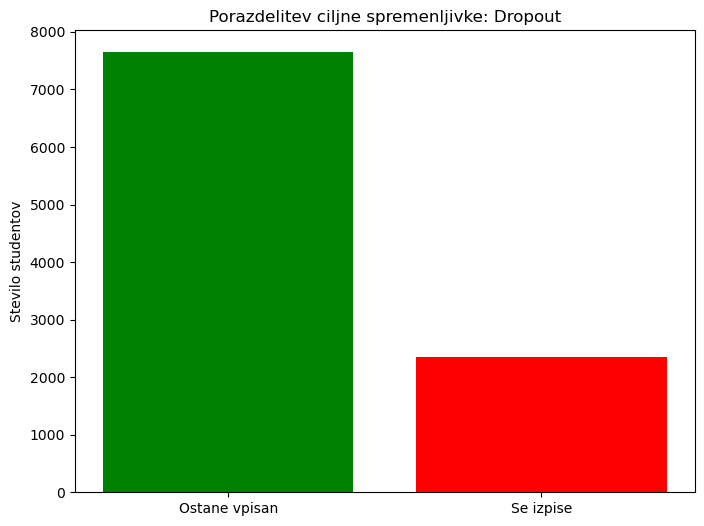

In [9]:
plt.figure(figsize=(8,6))
plt.bar(counts.index, counts.values,color=['green', 'red'])
plt.xticks([0,1], ['Ostane vpisan', 'Se izpise'])
plt.title('Porazdelitev ciljne spremenljivke: Dropout')
plt.ylabel('Stevilo studentov')
plt.savefig('porazdelitev_dropout.png')
plt.show()


## 2. Pregled podatkov

In [10]:
student_dropout.set_index('Student_ID', inplace = True)

In [11]:
student_dropout

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
Student_ID,,,,,,,,,,,,,,,,,,
1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,23.9,Female,42286.0,No,4.62,92.0,0,10.0,Yes,Yes,5.5,1.60,0.99,0.97,Year 2,Arts,Bachelor,0
9997,17.0,Female,61103.0,Yes,2.87,75.2,3,32.4,No,Yes,6.7,3.09,3.09,3.09,Year 1,Business,Master,1
9998,19.4,Male,25000.0,Yes,4.73,74.9,4,25.4,No,No,3.5,3.45,3.37,3.43,Year 4,Business,Bachelor,0


In [12]:
student_dropout.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 1 to 10000
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    10000 non-null  float64
 1   Gender                 10000 non-null  str    
 2   Family_Income          9500 non-null   float64
 3   Internet_Access        10000 non-null  str    
 4   Study_Hours_per_Day    9500 non-null   float64
 5   Attendance_Rate        10000 non-null  float64
 6   Assignment_Delay_Days  10000 non-null  int64  
 7   Travel_Time_Minutes    10000 non-null  float64
 8   Part_Time_Job          10000 non-null  str    
 9   Scholarship            10000 non-null  str    
 10  Stress_Index           9500 non-null   float64
 11  GPA                    10000 non-null  float64
 12  Semester_GPA           10000 non-null  float64
 13  CGPA                   10000 non-null  float64
 14  Semester               10000 non-null  str    
 15  Department   

In [13]:
categorical_columns =['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester', 'Department', 'Parental_Education']
numerical_columns = ['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 
                     'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA']

In [14]:
student_dropout['Gender'] = student_dropout['Gender'].astype('category')
student_dropout['Internet_Access'] = student_dropout['Internet_Access'].astype('category')  
student_dropout['Part_Time_Job'] = student_dropout['Part_Time_Job'].astype('category')
student_dropout['Scholarship'] = student_dropout['Scholarship'].astype('category')  
student_dropout['Semester'] = student_dropout['Semester'].astype('category')
student_dropout['Department'] = student_dropout['Department'].astype('category')
student_dropout['Parental_Education'] = student_dropout['Parental_Education'].astype('category')
student_dropout['Dropout'] = student_dropout['Dropout'].astype('category')


In [15]:
student_dropout.describe()

,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA
count,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000
mean,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761
std,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555
min,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000
25%,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000
50%,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000
75%,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000
max,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000


# 3.Train test split

In [16]:
from sklearn.model_selection import train_test_split
X = student_dropout.drop('Dropout', axis = 1)
y = student_dropout['Dropout']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
features = X_train.columns

In [17]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 8000 entries, 4566 to 6817
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Age                    8000 non-null   float64 
 1   Gender                 8000 non-null   category
 2   Family_Income          7593 non-null   float64 
 3   Internet_Access        8000 non-null   category
 4   Study_Hours_per_Day    7593 non-null   float64 
 5   Attendance_Rate        8000 non-null   float64 
 6   Assignment_Delay_Days  8000 non-null   int64   
 7   Travel_Time_Minutes    8000 non-null   float64 
 8   Part_Time_Job          8000 non-null   category
 9   Scholarship            8000 non-null   category
 10  Stress_Index           7593 non-null   float64 
 11  GPA                    8000 non-null   float64 
 12  Semester_GPA           8000 non-null   float64 
 13  CGPA                   8000 non-null   float64 
 14  Semester               8000 non-null   category
 15  

# 4.Predprocesiranje

### Imputing missing values

In [18]:
from sklearn.impute import SimpleImputer, KNNImputer
simple_imputer = SimpleImputer(strategy = 'most_frequent')
knn_imputer = KNNImputer(n_neighbors=5)

X_train[categorical_columns] = simple_imputer.fit_transform(X_train[categorical_columns])
X_test[categorical_columns] = simple_imputer.transform(X_test[categorical_columns])

X_train[numerical_columns] = knn_imputer.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = knn_imputer.transform(X_test[numerical_columns])

In [19]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 8000 entries, 4566 to 6817
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    8000 non-null   float64
 1   Gender                 8000 non-null   str    
 2   Family_Income          8000 non-null   float64
 3   Internet_Access        8000 non-null   str    
 4   Study_Hours_per_Day    8000 non-null   float64
 5   Attendance_Rate        8000 non-null   float64
 6   Assignment_Delay_Days  8000 non-null   float64
 7   Travel_Time_Minutes    8000 non-null   float64
 8   Part_Time_Job          8000 non-null   str    
 9   Scholarship            8000 non-null   str    
 10  Stress_Index           8000 non-null   float64
 11  GPA                    8000 non-null   float64
 12  Semester_GPA           8000 non-null   float64
 13  CGPA                   8000 non-null   float64
 14  Semester               8000 non-null   str    
 15  Department       

### One Hot Encoding

In [20]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop = 'first')

X_train_encoded = encoder.fit_transform(X_train[categorical_columns])
X_test_encoded = encoder.transform(X_test[categorical_columns])

#dobimo imena novih stolpcev
encoded_columns = encoder.get_feature_names_out(categorical_columns).tolist()

#spremenimo v dataframe
X_train_df = pd.DataFrame(X_train_encoded, columns = encoded_columns, index = X_train.index)
X_test_df = pd.DataFrame(X_test_encoded, columns = encoded_columns, index = X_test.index)

#dodamo numericne stolpce
X_train = pd.concat([X_train[numerical_columns], X_train_df], axis = 1)
X_test = pd.concat([X_test[numerical_columns], X_test_df], axis = 1)

#dobimo imena vseh stolpcev
all_columns = X_train.columns.tolist()


In [21]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 8000 entries, 4566 to 6817
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             8000 non-null   float64
 1   Family_Income                   8000 non-null   float64
 2   Study_Hours_per_Day             8000 non-null   float64
 3   Attendance_Rate                 8000 non-null   float64
 4   Assignment_Delay_Days           8000 non-null   float64
 5   Travel_Time_Minutes             8000 non-null   float64
 6   Stress_Index                    8000 non-null   float64
 7   GPA                             8000 non-null   float64
 8   Semester_GPA                    8000 non-null   float64
 9   CGPA                            8000 non-null   float64
 10  Gender_Male                     8000 non-null   float64
 11  Internet_Access_Yes             8000 non-null   float64
 12  Part_Time_Job_Yes               8000 non-null  

### Standardizacija podatkov

In [22]:
numerical_columns

['Age',
 'Family_Income',
 'Study_Hours_per_Day',
 'Attendance_Rate',
 'Assignment_Delay_Days',
 'Travel_Time_Minutes',
 'Stress_Index',
 'GPA',
 'Semester_GPA',
 'CGPA']

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#scaliramo
X_train_scaled = scaler.fit_transform(X_train[numerical_columns])
X_test_scaled = scaler.transform(X_test[numerical_columns])

#pretvorimo v dataframe
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = numerical_columns, index = X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns = numerical_columns, index = X_test.index)

#dodamo v X_train in X_test
X_train[numerical_columns] = X_train_scaled_df
X_test[numerical_columns] = X_test_scaled_df

In [24]:
X_train.describe()

,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,...,Semester_Year 2,Semester_Year 3,Semester_Year 4,Department_Business,Department_CS,Department_Engineering,Department_Science,Parental_Education_High School,Parental_Education_Master,Parental_Education_PhD
count,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,...,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000,8000.000000
mean,-7.251977e-16,-5.107026e-17,2.258194e-16,5.835332e-16,-9.592327e-17,-7.016610e-17,-4.440892e-17,2.171596e-16,6.239453e-17,-1.374456e-16,...,0.253625,0.252875,0.250125,0.200125,0.197375,0.194000,0.208750,0.305750,0.20125,0.047625
std,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,...,0.435113,0.434687,0.433112,0.400119,0.398043,0.395454,0.406441,0.460753,0.40096,0.212985
min,-1.874983e+00,-6.606182e-01,-2.762076e+00,-4.913700e+00,-1.331355e+00,-2.114934e+00,-2.591333e+00,-2.174233e+00,-2.141737e+00,-2.142996e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,-7.065401e-01,-6.606182e-01,-6.493127e-01,-6.523278e-01,-5.866971e-01,-6.933032e-01,-6.987177e-01,-7.054396e-01,-7.264999e-01,-7.260127e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,-5.474156e-03,-4.013988e-01,-5.273464e-03,1.731639e-02,1.579605e-01,7.871236e-04,-1.049398e-02,2.895688e-02,4.629433e-02,4.773462e-02,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
75%,6.955918e-01,2.909909e-01,6.387658e-01,6.869606e-01,9.026181e-01,6.886056e-01,6.777298e-01,7.727687e-01,8.004670e-01,7.935152e-01,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000
max,3.967233e+00,1.098710e+01,3.898233e+00,2.221055e+00,4.625906e+00,3.730478e+00,2.570345e+00,1.591903e+00,1.582572e+00,1.585907e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000


# 5. Feature selection

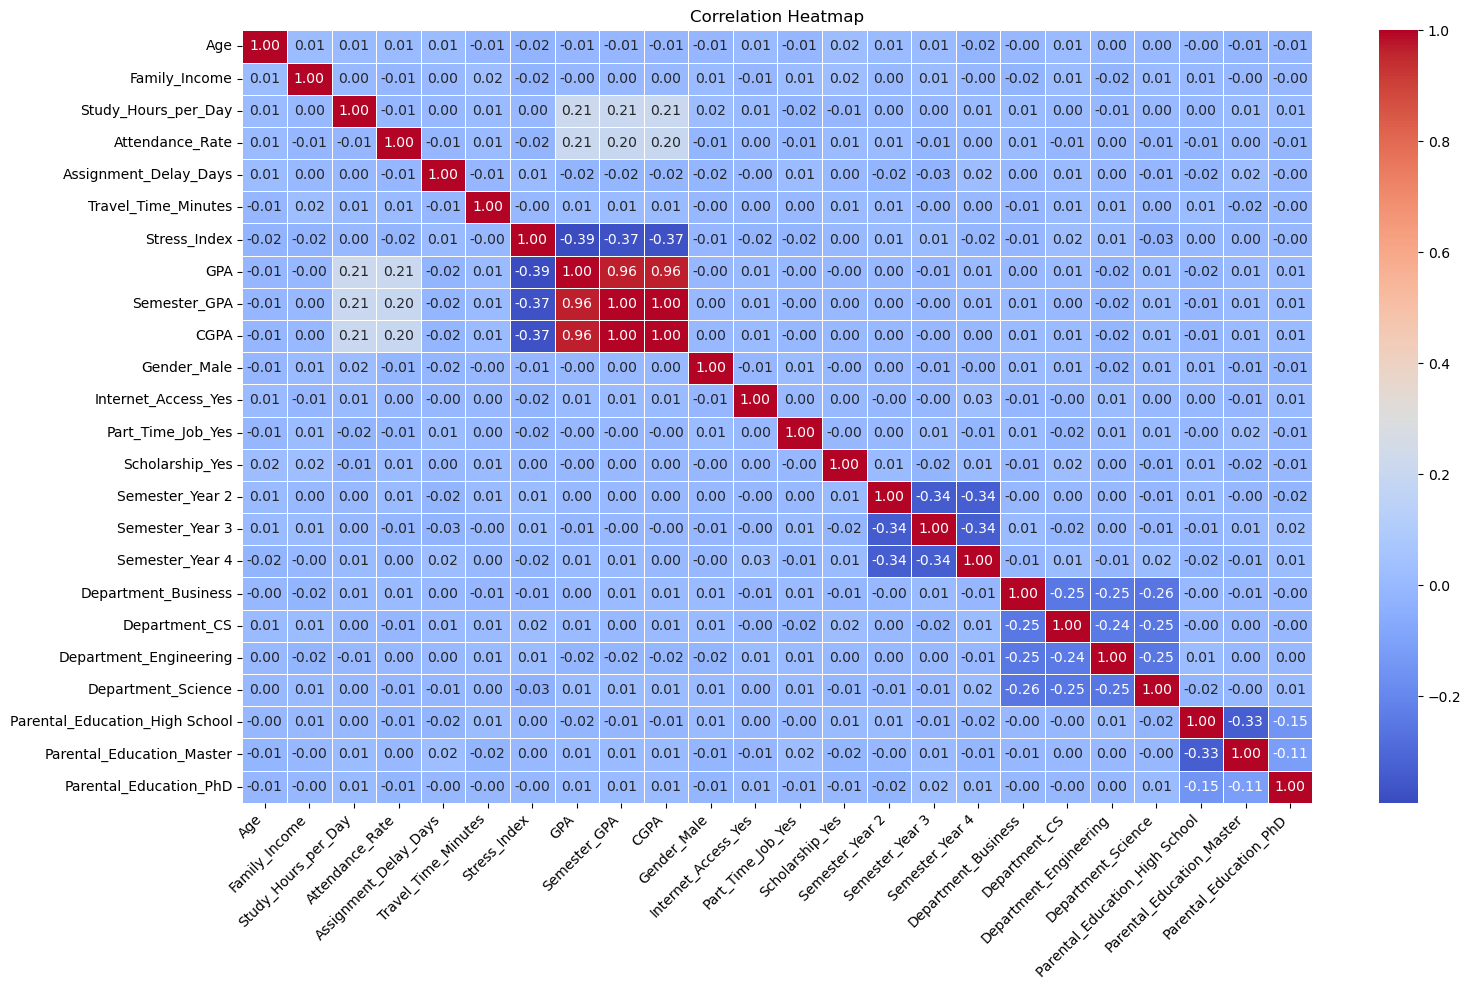

In [25]:
plt.figure(figsize=(16,10))
sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.xticks(rotation=45, ha='right')
plt.title('Correlation Heatmap')
plt.tight_layout()


### PCA

In [26]:
#PCA za visoko korelirane sprem. (CPA, Semester_GPA, CGPA)
from sklearn.decomposition import PCA

pca = PCA(n_components = 1)
X_train_pca = pca.fit_transform(X_train[['GPA', 'Semester_GPA', 'CGPA']])

print("Pojasnjena varianca:", pca.explained_variance_ratio_)

Pojasnjena varianca: [0.98367208]


In [27]:
X_train_pca.shape

(8000, 1)

In [28]:
X_test_pca = pca.transform(X_test[['GPA', 'Semester_GPA', 'CGPA']])

#odstranimo stolpce
X_train = X_train.drop(columns=['GPA', 'Semester_GPA', 'CGPA'])
X_test  = X_test.drop(columns=['GPA', 'Semester_GPA', 'CGPA'])

#dodamo novo PCA
X_train['Student_Performance'] = X_train_pca[:, 0]
X_test['Student_Performance']  = X_test_pca[:, 0]

print(X_train.columns)

Index(['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate',
       'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index',
       'Gender_Male', 'Internet_Access_Yes', 'Part_Time_Job_Yes',
       'Scholarship_Yes', 'Semester_Year 2', 'Semester_Year 3',
       'Semester_Year 4', 'Department_Business', 'Department_CS',
       'Department_Engineering', 'Department_Science',
       'Parental_Education_High School', 'Parental_Education_Master',
       'Parental_Education_PhD', 'Student_Performance'],
      dtype='str')


In [29]:
all_columns = X_train.columns.tolist()
all_columns

['Age',
 'Family_Income',
 'Study_Hours_per_Day',
 'Attendance_Rate',
 'Assignment_Delay_Days',
 'Travel_Time_Minutes',
 'Stress_Index',
 'Gender_Male',
 'Internet_Access_Yes',
 'Part_Time_Job_Yes',
 'Scholarship_Yes',
 'Semester_Year 2',
 'Semester_Year 3',
 'Semester_Year 4',
 'Department_Business',
 'Department_CS',
 'Department_Engineering',
 'Department_Science',
 'Parental_Education_High School',
 'Parental_Education_Master',
 'Parental_Education_PhD',
 'Student_Performance']

In [30]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 8000 entries, 4566 to 6817
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             8000 non-null   float64
 1   Family_Income                   8000 non-null   float64
 2   Study_Hours_per_Day             8000 non-null   float64
 3   Attendance_Rate                 8000 non-null   float64
 4   Assignment_Delay_Days           8000 non-null   float64
 5   Travel_Time_Minutes             8000 non-null   float64
 6   Stress_Index                    8000 non-null   float64
 7   Gender_Male                     8000 non-null   float64
 8   Internet_Access_Yes             8000 non-null   float64
 9   Part_Time_Job_Yes               8000 non-null   float64
 10  Scholarship_Yes                 8000 non-null   float64
 11  Semester_Year 2                 8000 non-null   float64
 12  Semester_Year 3                 8000 non-null  

## 4. Modeli

### Tree Classifier

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

parameters = {
    'criterion':['gini', 'entropy'],
    'max_depth':[3, 5, 7, 10, 13],
    'min_samples_split':[2,3, 5, 7,10],
    'min_samples_leaf':[2,3, 5,7,10],
}

tree = DecisionTreeClassifier(random_state=42, class_weight= 'balanced')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(tree, parameters, cv = cv, scoring='f1')
grid_search.fit(X_train, y_train)

print('Best criterion:', grid_search.best_params_['criterion'])
print('Best max_depth:', grid_search.best_params_['max_depth'])
print('Best min_samples_split:', grid_search.best_params_['min_samples_split'])
print('Best min_samples_leaf:', grid_search.best_params_['min_samples_leaf'])

Best criterion: gini
Best max_depth: 3
Best min_samples_split: 2
Best min_samples_leaf: 2


In [32]:
tree = DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_split=2, min_samples_leaf=2,  random_state=42, class_weight='balanced')
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
print('Tocnost na ucnih podatkih: {:.3f}'.format(tree.score(X_train, y_train)))
print('Tocnost na testnih podatkih: {:.3f}'.format(tree.score(X_test, y_test)))


Tocnost na ucnih podatkih: 0.726
Tocnost na testnih podatkih: 0.721


### Plotting tree

In [38]:
print(tree.classes_) #0-retained, 1-dropped_out

[0 1]


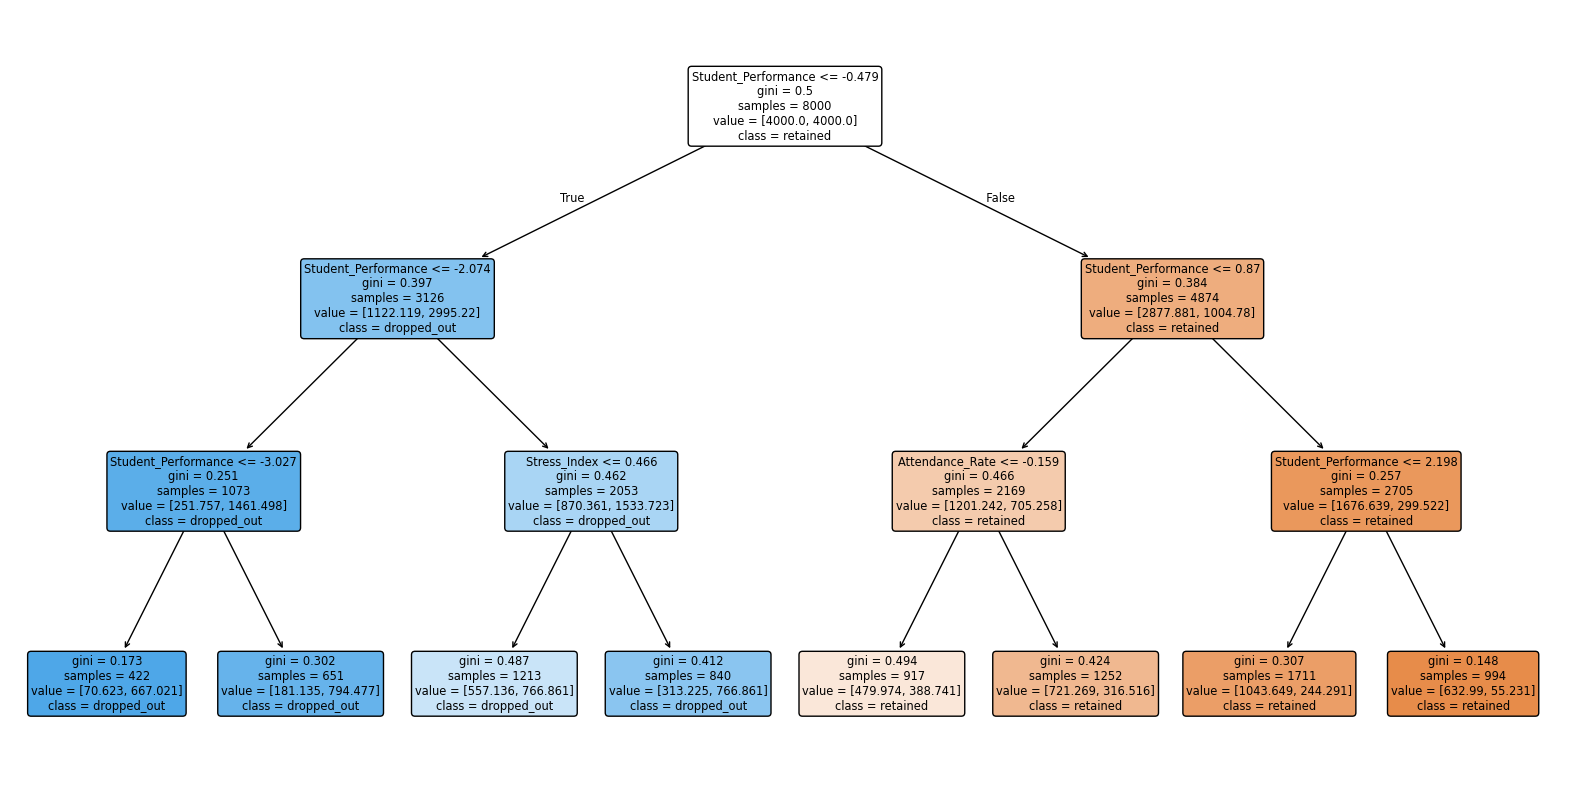

In [39]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=X_train.columns, class_names=['retained', 'dropped_out'], filled=True, rounded=True)
plt.savefig('tree.png')
plt.show()

### Feature importance

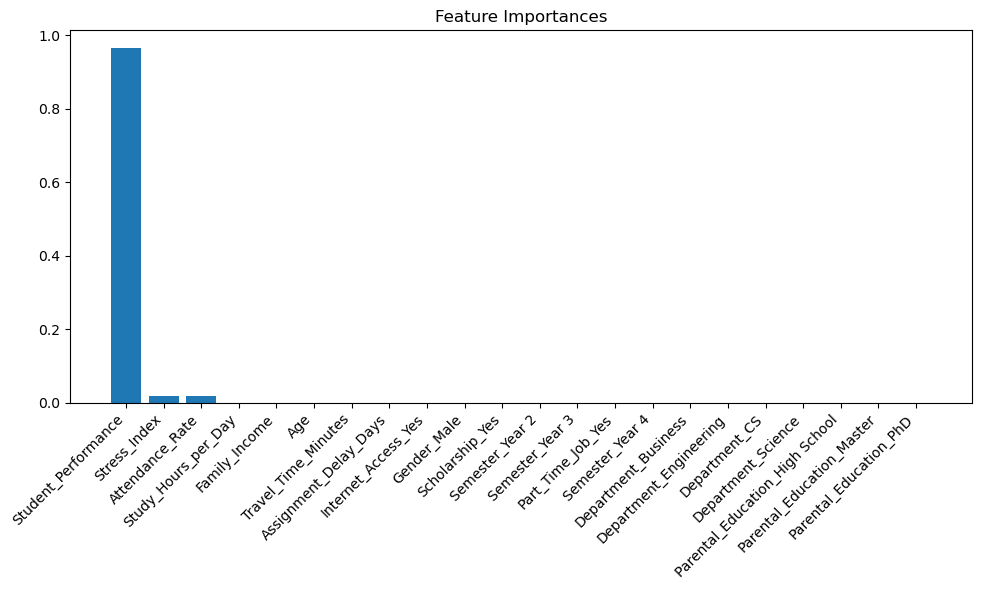

In [41]:
importances = pd.Series(tree.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(importances.index, importances.values)
plt.xticks(rotation=45, ha='right')
plt.title('Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance_tree.png')
plt.show()

In [42]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_tree)
cm

array([[1090,  439],
       [ 119,  352]])

In [43]:
from sklearn.metrics import classification_report
cr = classification_report(y_test, y_pred_tree, target_names=['Retained', 'Dropped Out'])
print(cr)

              precision    recall  f1-score   support

    Retained       0.90      0.71      0.80      1529
 Dropped Out       0.45      0.75      0.56       471

    accuracy                           0.72      2000
   macro avg       0.67      0.73      0.68      2000
weighted avg       0.79      0.72      0.74      2000



In [ ]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

#auc
y_pred_proba = tree.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)

#pr
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

ROC-AUC: 0.789
PR-AUC: 0.547


### Random Forest

In [50]:
from sklearn.ensemble import RandomForestClassifier

parameters_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 10],
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(rf, parameters_rf, cv=cv, scoring='f1')
grid_search.fit(X_train, y_train)

print("Best n_estimators:", grid_search.best_params_['n_estimators'])
print("Best max_depth:", grid_search.best_params_['max_depth'])
print("Best min_samples_split:", grid_search.best_params_['min_samples_split'])
print("Best min_samples_leaf:", grid_search.best_params_['min_samples_leaf'])


Best n_estimators: 200
Best max_depth: 10
Best min_samples_split: 10
Best min_samples_leaf: 4


In [51]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=10, min_samples_leaf=4, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Tocnost na ucnih podatkih: {:.3f}'.format(rf.score(X_train, y_train)))
print('Tocnost na testnih podatkih: {:.3f}'.format(rf.score(X_test, y_test)))


Tocnost na ucnih podatkih: 0.830
Tocnost na testnih podatkih: 0.764


array([[1214,  315],
       [ 157,  314]])

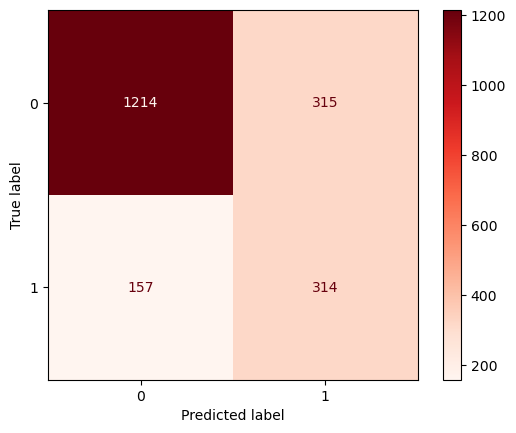

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_rf)
display = ConfusionMatrixDisplay(cm, display_labels=rf.classes_)
display.plot(cmap=plt.cm.Reds)
cm

In [54]:
from sklearn.metrics import classification_report, accuracy_score
cr = classification_report(y_test, y_pred_rf, target_names=['Retained', 'Dropped Out'])
print(cr)

              precision    recall  f1-score   support

    Retained       0.89      0.79      0.84      1529
 Dropped Out       0.50      0.67      0.57       471

    accuracy                           0.76      2000
   macro avg       0.69      0.73      0.70      2000
weighted avg       0.79      0.76      0.77      2000



In [56]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

#auc
y_pred_proba = rf.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)

#pr
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

ROC-AUC: 0.809
PR-AUC: 0.570


### GRADIENT BOOSTING

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

parameters = {
    'n_estimators':[50, 100, 150, 200],
    'learning_rate':[0.01, 0.05, 0.1],
    'max_depth':list(range(2,5))
}

gbc = GradientBoostingClassifier(random_state = 42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(gbc, parameters, cv = cv, scoring = 'f1')
grid_search.fit(X_train, y_train)
print('Best n_estimators:', grid_search.best_params_['n_estimators'])
print('Best learning_rate:', grid_search.best_params_['learning_rate'])
print('Best max_depth:', grid_search.best_params_['max_depth'])

Best n_estimators: 150
Best learning_rate: 0.1
Best max_depth: 3


In [59]:
gbc = GradientBoostingClassifier(n_estimators=150, learning_rate = 0.05, max_depth=3, random_state=42)
gbc.fit(X_train, y_train)
y_pred_gbc = gbc.predict(X_test)
print('Accuracy on test data: {:.3f}'.format(gbc.score(X_test, y_test)))
print('Accuracy on training data: {:.3f}'.format(gbc.score(X_train,y_train)))

Accuracy on test data: 0.801
Accuracy on training data: 0.824


array([[1431,   98],
       [ 300,  171]])

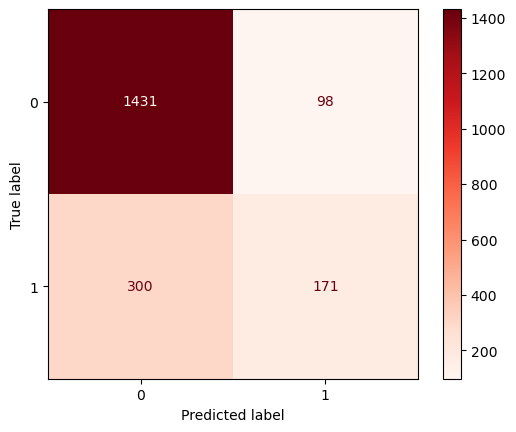

In [60]:
cm = confusion_matrix(y_test, y_pred_gbc)
display = ConfusionMatrixDisplay(cm, display_labels=gbc.classes_)
display.plot(cmap=plt.cm.Reds)
cm

In [61]:
cr = classification_report(y_test, y_pred_gbc, target_names=['Retained', 'Dropped Out'])
print(cr)

              precision    recall  f1-score   support

    Retained       0.83      0.94      0.88      1529
 Dropped Out       0.64      0.36      0.46       471

    accuracy                           0.80      2000
   macro avg       0.73      0.65      0.67      2000
weighted avg       0.78      0.80      0.78      2000



In [64]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

#auc
y_pred_proba = gbc.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)

#pr
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

ROC-AUC: 0.813
PR-AUC: 0.561


### SVM

In [75]:
from sklearn.svm import SVC
svc = SVC(kernel='rbf')

parameters = {
    'C': [0.01, 0.1, 1, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(svc,parameters,cv=cv,scoring='f1')
grid_search.fit(X_train, y_train)

print("Best C:", grid_search.best_params_['C'])

Best C: 10


In [69]:
svc = SVC(kernel = 'rbf', C =1, gamma = 'scale', random_state = 42, class_weight='balanced', probability=True)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)
print('Accuracy on training data: {:.3f}'.format(svc.score(X_train, y_train)))
print('Accuracy on test data: {:.3f}'.format(svc.score(X_test, y_test)))


Accuracy on training data: 0.773
Accuracy on test data: 0.737


array([[1123,  406],
       [ 120,  351]])

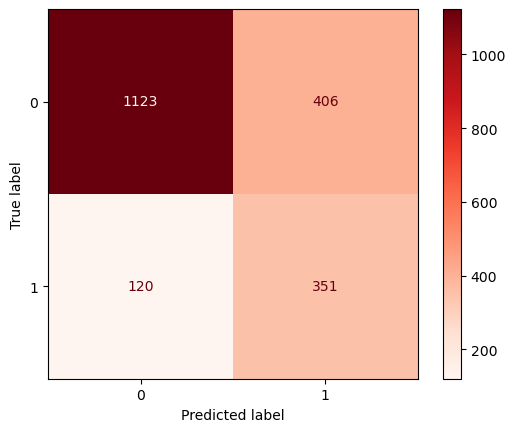

In [70]:
cm = confusion_matrix(y_test, y_pred_svc)
display = ConfusionMatrixDisplay(cm, display_labels=svc.classes_)
display.plot(cmap=plt.cm.Reds)
cm

In [71]:
cr = classification_report(y_test, y_pred_svc, target_names=['Retained', 'Dropped Out'])
print(cr)

              precision    recall  f1-score   support

    Retained       0.90      0.73      0.81      1529
 Dropped Out       0.46      0.75      0.57       471

    accuracy                           0.74      2000
   macro avg       0.68      0.74      0.69      2000
weighted avg       0.80      0.74      0.75      2000



In [72]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

#auc
y_pred_proba = svc.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)

#pr
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

ROC-AUC: 0.797
PR-AUC: 0.518
